In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
n_qubits = 1
dev = qml.device("default.qubit",wires=n_qubits)

In [3]:

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

@qml.qnode(dev)
def circuit(weights, x):

    wires=[wire for wire in range(n_qubits)]

    qml.StatePrep(x,wires=wires,normalize=True,pad_with=0.1)

    for layer_weights in weights:
        layer(layer_weights)
    

    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            qml.CNOT(wires=[i, j])
    

def cost(weights, bias, X, Y):

    predictions = variational_classifier(weights, bias, X)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [4]:

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [5]:
imp=IterativeImputer(random_state=42)
enc=LabelEncoder()
scaler=RobustScaler()
pca=PCA(n_components=np.power(2,n_qubits))
minmaxscaler=MinMaxScaler()

In [6]:

top_feats_df = pd.read_csv(f"./classical_approach/data/top_{np.power(2,n_qubits)}_features.csv")
top_feats = top_feats_df["Feature"].tolist()
top_feats

['area_se', 'area_worst']

In [7]:
df_train=pd.read_csv('./cancer_data/clean_train_subset.csv')
class_imbalance(data_df=df_train)

y_train=df_train['diagnosis'].values
y_train = np.array(y_train, requires_grad=False)

id=df_train['id']
x_train=df_train.drop(columns=['diagnosis','id'])
x_train=x_train[top_feats]
x_train.head()

Absolute frequencies of field "diagnosis"
diagnosis
-1    214
 1    127
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627566
 1    0.372434
Name: proportion, dtype: float64


,area_se,area_worst
0,35.24,925.1
1,22.73,385.2
2,19.98,831.0
3,70.10,1313.0
4,35.13,558.9


In [8]:
# x_scaled_train=scaler.fit_transform(x_train)

# X_pca = pca.fit_transform(x_scaled_train)

# print(np.sum(pca.explained_variance_ratio_))

In [9]:
# # Put back into a DataFrame if you want
# df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# df_pca['diagnosis'] = y_train
# df_pca['id']=id.reset_index(drop=True)

# df_pca.head()

In [10]:
# df_pca.to_csv('./pca_datasets/pca2_clean_train_subset.csv',index=False)

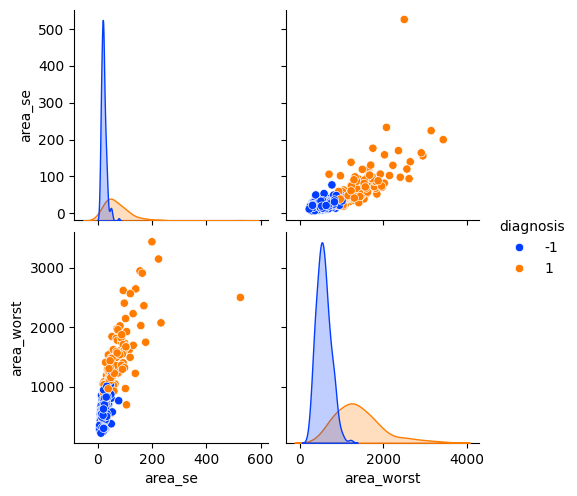

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# classes = x_train["diagnosis"].unique()

# Define the number of features per plot
n = 6 

# Loop through the features in chunks of n
for i in range(0, len(top_feats), n):
    subset = top_feats[i:i+n]
    
    # Create the pairplot for this subset, coloring by Diagnosis
    sns.pairplot(df_train, vars=subset, hue='diagnosis',palette='bright')
    plt.show()

In [12]:
# y_pca_train=df_pca['diagnosis']
# x_pca_train=df_pca.drop(columns=['diagnosis','id'])
x_pca_train=np.array(x_train,requires_grad=False)
x_pca_train=minmaxscaler.fit_transform(x_pca_train)

In [13]:
print(f"First X sample (original)  : {x_pca_train[0]}")

First X sample (original)  : [0.05481517 0.21864481]


In [14]:
features = np.array(x_pca_train, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)

In [15]:
df_val=pd.read_csv('./cancer_data/clean_val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

y_val=df_val['diagnosis'].values

Absolute frequencies of field "diagnosis"
diagnosis
-1    71
 1    43
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.622807
 1    0.377193
Name: proportion, dtype: float64


In [16]:
id_val=df_val['id']
x_val=df_val.drop(columns=['diagnosis','id'])
x_val=x_val[top_feats]
x_val.head()

,area_se,area_worst
0,16.26,547.4
1,13.38,553.7
2,18.24,364.2
3,15.34,550.6
4,17.37,566.9


In [17]:
# x_scaled_val=scaler.transform(x_val)

# X_pca_val = pca.transform(x_scaled_val)


In [18]:
# # Put back into a DataFrame if you want
# df_pca_val = pd.DataFrame(X_pca_val, columns=['PC1', 'PC2'])
# df_pca_val['diagnosis'] = y_val
# df_pca_val['id']=id_val.reset_index(drop=True)

# df_pca_val.head()

In [19]:
# df_pca_val.to_csv('./pca_datasets/pca2_clean_val_subset.csv',index=False)

In [20]:
# y_pca_val=df_pca_val['diagnosis']
# x_pca_val=df_pca_val.drop(columns=['diagnosis','id'])
x_pca_val=np.array(x_val,requires_grad=False)
x_pca_val=minmaxscaler.transform(x_pca_val)

In [21]:
print(f"First X VAL sample (original)  : {x_pca_val[0]}")

First X VAL sample (original)  : [0.0182306  0.10092258]


In [22]:
features_val = np.array(x_pca_val, requires_grad=False)
y_val = np.array(y_val, requires_grad=False)

In [23]:
df_test=pd.read_csv('./cancer_data/clean_test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
-1    72
 1    42
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631579
 1    0.368421
Name: proportion, dtype: float64


In [24]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test=x_clean_test[top_feats]
x_clean_test.head()

,area_se,area_worst
0,16.160,567.9
1,24.190,745.5
2,9.227,544.1
3,22.770,467.2
4,14.670,630.5


In [25]:
# x_scaled_test=scaler.transform(x_clean_test)

# X_pca_test = pca.transform(x_scaled_test)

# print(pca.explained_variance_ratio_)

In [26]:
# y_test=df_test['diagnosis'].values
# id_test=df_test['id']
# x_clean_test=df_test.drop(columns=['diagnosis','id'])
# x_clean_test.head()

In [27]:
# df_pca_test = pd.DataFrame(X_pca_test, columns=['PC1', 'PC2'])
# df_pca_test['diagnosis'] = y_test
# df_pca_test['id']=id_test.reset_index(drop=True)

# df_pca_test.head()

In [28]:
# df_pca_test.to_csv('./pca_datasets/pca2_clean_test_subset.csv',index=False)

In [29]:
# y_pca_test=df_pca_test['diagnosis']
# x_pca_test=df_pca_test.drop(columns=['diagnosis','id'])
x_pca_test=np.array(x_clean_test)
x_pca_test=minmaxscaler.transform(x_pca_test)

In [30]:
features_test = np.array(x_pca_test, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)


 Test Set Evaluation achieved at epoch 87 (Number of layers 1):
Accuracy : 0.5614
Precision: 0.5843
Recall   : 0.5883
F1-score : 0.5602

 Test Set Evaluation achieved at epoch 282 (Number of layers 2):
Accuracy : 0.5614
Precision: 0.5843
Recall   : 0.5883
F1-score : 0.5602

 Test Set Evaluation achieved at epoch 279 (Number of layers 3):
Accuracy : 0.5526
Precision: 0.5725
Recall   : 0.5764
F1-score : 0.5509

 Test Set Evaluation achieved at epoch 45 (Number of layers 4):
Accuracy : 0.5614
Precision: 0.5843
Recall   : 0.5883
F1-score : 0.5602

 Test Set Evaluation achieved at epoch 85 (Number of layers 5):
Accuracy : 0.5614
Precision: 0.5843
Recall   : 0.5883
F1-score : 0.5602

 Test Set Evaluation achieved at epoch 11 (Number of layers 6):
Accuracy : 0.5526
Precision: 0.5725
Recall   : 0.5764
F1-score : 0.5509

 Test Set Evaluation achieved at epoch 12 (Number of layers 7):
Accuracy : 0.5526
Precision: 0.5725
Recall   : 0.5764
F1-score : 0.5509

 Test Set Evaluation achieved at epoch

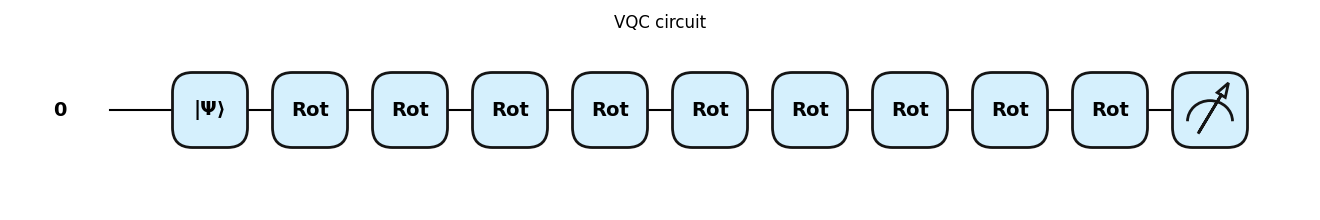

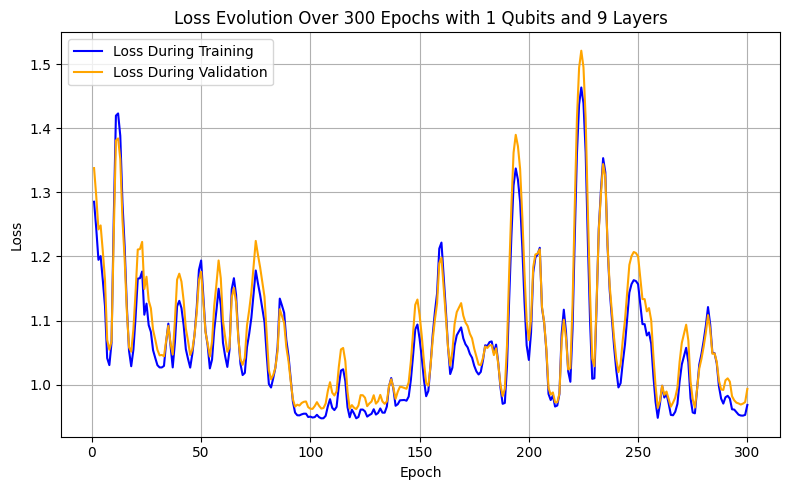

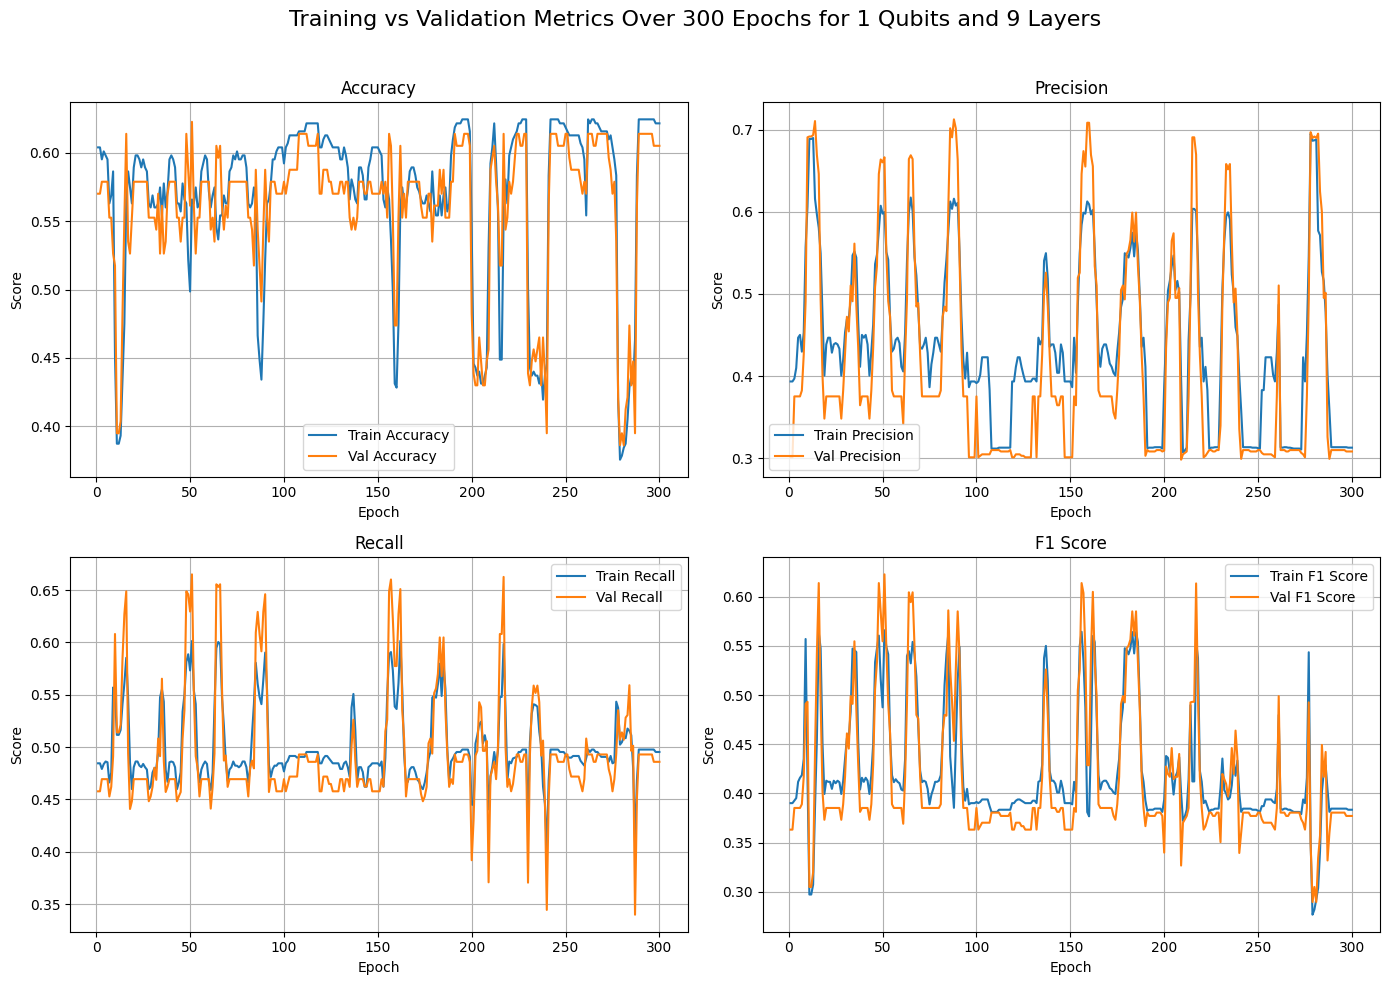

In [31]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 300

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

test_acc=[]
test_prec=[]
test_rec=[]
test_f1=[]

best_epoch=0
biased=False

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5

    # Tracking loss
    losses = []
    losses_val = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        val_cost = cost(weights, bias, features_val, y_val)

        losses.append(_cost)
        losses_val.append(val_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    test_acc.append(acc_test)
    test_prec.append(prec_test)
    test_rec.append(rec_test)
    test_f1.append(f1_test)


    print(f"\n Test Set Evaluation achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias

        best_losses=losses
        best_val_losses=losses_val
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

# np.savez("./model_params/1_run/unbiased/1_qubit/unbiased_params_1_qubits_1_run.npz", weights=best_weights, bias=best_bias)

print(f"\n--> Test Set Evaluation achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


 Test Set Evaluation for BIASED Classifier achieved at epoch 94 (Number of layers 1):
Accuracy : 0.5614
Precision: 0.5843
Recall   : 0.5883
F1-score : 0.5602

 Test Set Evaluation for BIASED Classifier achieved at epoch 160 (Number of layers 2):
Accuracy : 0.6140
Precision: 0.3125
Recall   : 0.4861
F1-score : 0.3804

 Test Set Evaluation for BIASED Classifier achieved at epoch 181 (Number of layers 3):
Accuracy : 0.6316
Precision: 0.4211
Recall   : 0.6667
F1-score : 0.5161

 Test Set Evaluation for BIASED Classifier achieved at epoch 108 (Number of layers 4):
Accuracy : 0.6140
Precision: 0.3125
Recall   : 0.4861
F1-score : 0.3804

 Test Set Evaluation for BIASED Classifier achieved at epoch 136 (Number of layers 5):
Accuracy : 0.6140
Precision: 0.3125
Recall   : 0.4861
F1-score : 0.3804

 Test Set Evaluation for BIASED Classifier achieved at epoch 11 (Number of layers 6):
Accuracy : 0.5526
Precision: 0.5725
Recall   : 0.5764
F1-score : 0.5509

 Test Set Evaluation for BIASED Classifie

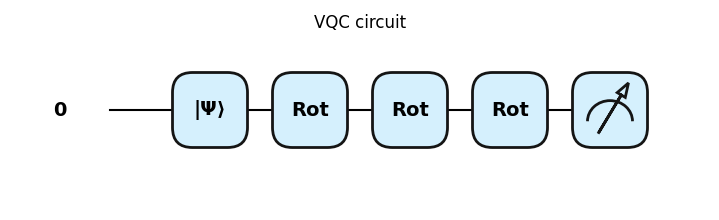

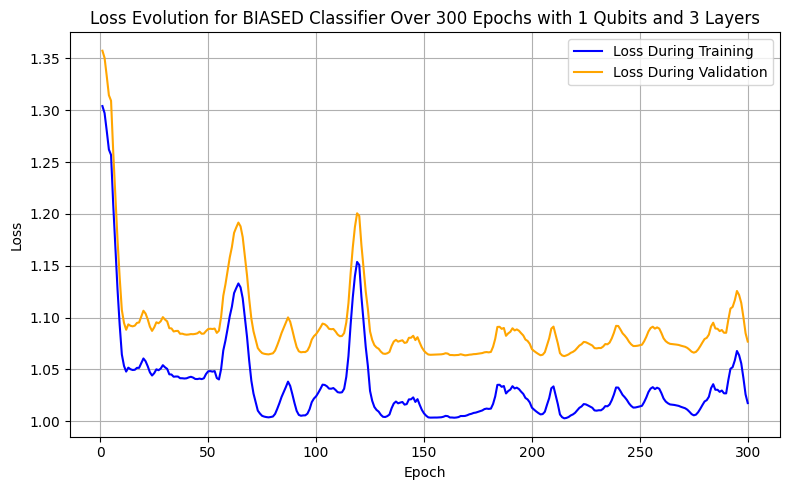

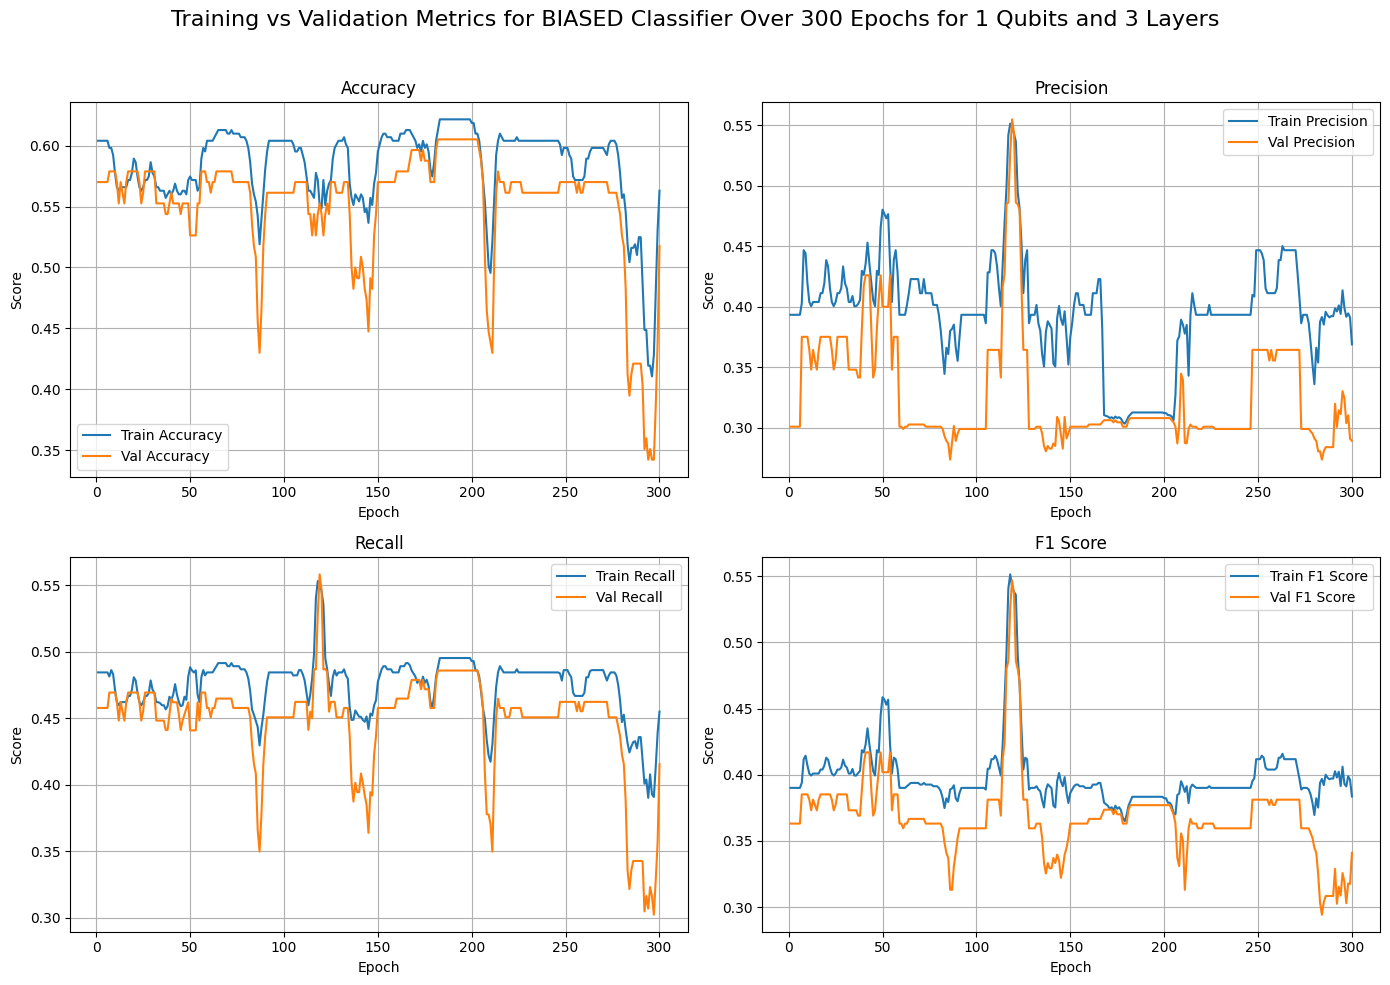

In [32]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 300

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0

best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

biased_test_acc=[]
biased_test_prec=[]
biased_test_rec=[]
biased_test_f1=[]

best_epoch=0
biased=True

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5

    # Tracking loss
    losses = []
    val_losses=[]

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        
        _cost = cost(weights, bias, features, y_train)
        val_cost = cost(weights, bias, features_val, y_val)

        losses.append(_cost)
        val_losses.append(val_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    biased_test_acc.append(acc_test)
    biased_test_prec.append(prec_test)
    biased_test_rec.append(rec_test)
    biased_test_f1.append(f1_test)


    print(f"\n Test Set Evaluation for BIASED Classifier achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias.copy()

        best_losses=losses
        best_val_losses=val_losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

# np.savez("./model_params/1_run/biased/1_qubit/biased_params_1_qubits_1_run.npz", weights=best_weights, bias=best_bias)

print(f"\n--> Test Set Evaluation for BIASED achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution for BIASED Classifier Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics for BIASED Classifier Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your lists are already populated:
# layers, biased_test_acc, test_acc, etc.

# Create a structured DataFrame
data = []
for i, layer in enumerate(layers):
    # Add Biased Data
    data.append({'Layers': layer, 'Score': biased_test_acc[i], 'Metric': 'Accuracy', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_prec[i], 'Metric': 'Precision', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_rec[i], 'Metric': 'Recall', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_f1[i], 'Metric': 'F1', 'Type': 'Biased'})
    
    # Add Unbiased Data
    data.append({'Layers': layer, 'Score': test_acc[i], 'Metric': 'Accuracy', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_prec[i], 'Metric': 'Precision', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_rec[i], 'Metric': 'Recall', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_f1[i], 'Metric': 'F1', 'Type': 'Unbiased'})

df = pd.DataFrame(data)

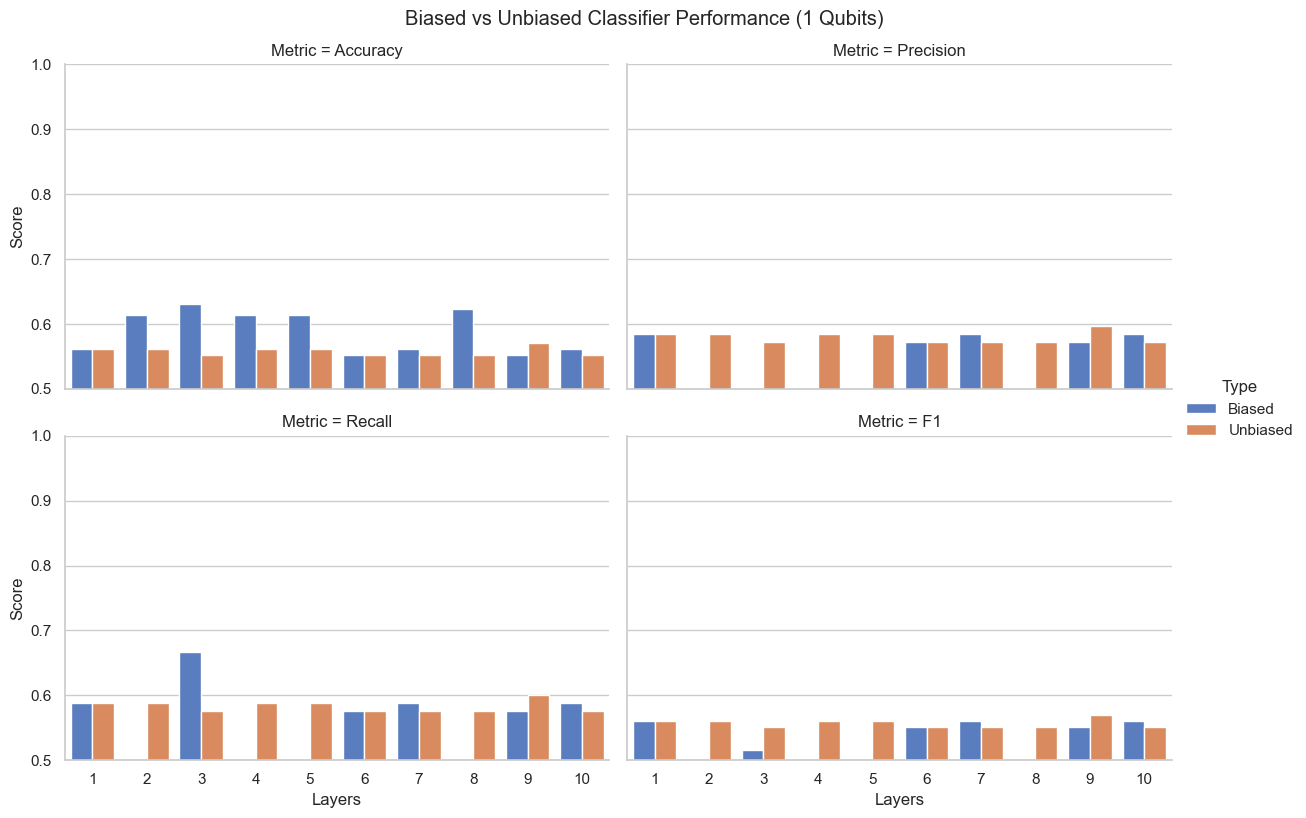

In [34]:
# Set a clean theme
sns.set_theme(style="whitegrid")

# Create the plot
g = sns.catplot(
    data=df, 
    x="Layers", 
    y="Score", 
    hue="Type", 
    col="Metric", 
    kind="bar", 
    col_wrap=2,   # 2 plots per row
    height=4, 
    aspect=1.5,
    palette="muted"
)

# Adjust the Y-axis to focus on the relevant range (optional)
# If you want to see the full 0-1 scale, remove the set_ylim line.
g.set(ylim=(0.5, 1.0)) 

# Add titles
g.figure.suptitle(f'Biased vs Unbiased Classifier Performance ({num_qubits} Qubits)', y=1.02)
plt.show()

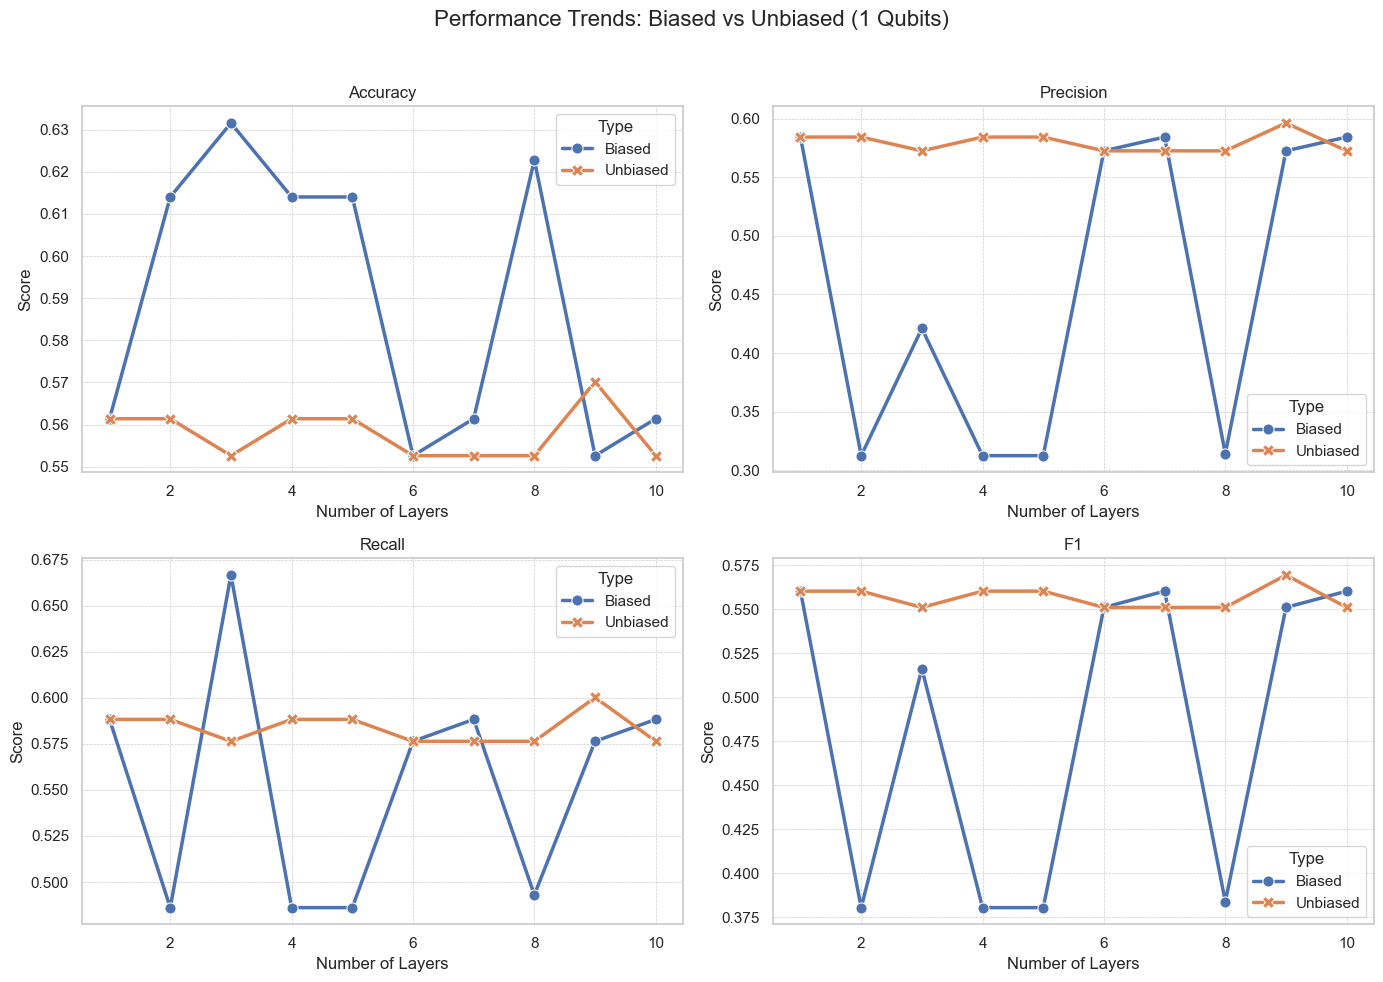

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

# Flatten axes for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Filter data for the specific metric
    subset = df[df['Metric'] == metric]
    
    sns.lineplot(
        data=subset, 
        x="Layers", 
        y="Score", 
        hue="Type", 
        style="Type", 
        markers=True,  # Adds dots at data points
        dashes=False, 
        ax=axes[i],
        linewidth=2.5,
        markersize=8
    )
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Number of Layers")
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.suptitle(f'Performance Trends: Biased vs Unbiased ({num_qubits} Qubits)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

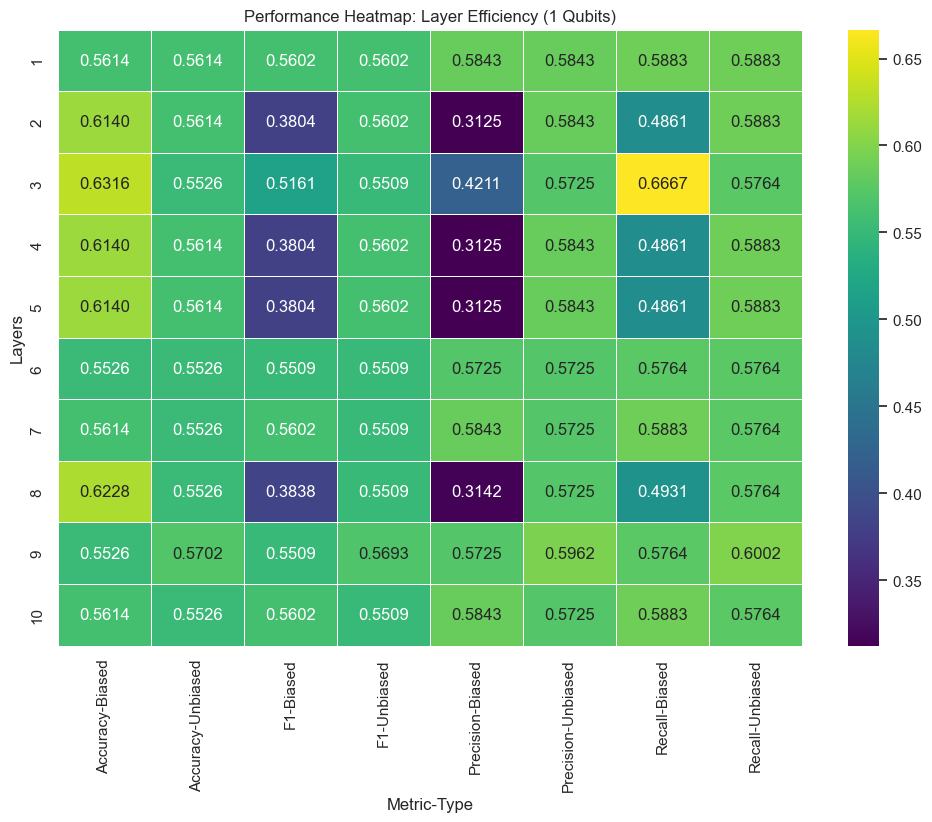

In [36]:
# Pivot data for heatmap: Rows = Layers, Cols = Metric + Type
heatmap_data = df.pivot_table(index="Layers", columns=["Metric", "Type"], values="Score")

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Show the actual numbers
    fmt=".4f",       # 4 decimal places
    cmap="viridis",  # Color scheme
    linewidths=.5
)
plt.title(f"Performance Heatmap: Layer Efficiency ({num_qubits} Qubits)")
plt.show()

In [37]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {np.mean(metrics_dict['accuracy']):.4f}")
    print(f"  Precision: {np.mean(metrics_dict['precision']):.4f}")
    print(f"  Recall   : {np.mean(metrics_dict['recall']):.4f}")
    print(f"  F1-Score : {np.mean(metrics_dict['f1']):.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [38]:
# # Classical ML method: SVM
# svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
# svm_clf.fit(x_pca_train, y_train)

# y_test_pred = svm_clf.predict(X_pca_test)

# test_dict = {
#     "accuracy": accuracy_score(y_test, y_test_pred),
#     "precision": precision_score(y_test, y_test_pred),
#     "recall": recall_score(y_test, y_test_pred),
#     "f1": f1_score(y_test, y_test_pred),
# }

# print("\n-----> SVM Results <-----")
# print_metrics(test_dict, "Test")

# Classical ML method: Logistic Regression

lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_pca_train, y_train)

y_test_pred = lr_clf.predict(x_pca_test)

test_dict = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred),
    "recall": recall_score(y_test, y_test_pred),
    "f1": f1_score(y_test, y_test_pred),
}

print("\n-----> Logistic Regression Results for 1 Run <-----")
print_metrics(test_dict, "Test")

# np.save("./results/lr/1_run/1_qubit/lr_metrics_dict.npy", test_dict, allow_pickle=True)

np.random.seed(42)
cs=np.random.rand(10).tolist()

# print(cs)

test_dict = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
}

for c in cs:
    lr_clf = LogisticRegression(random_state=42,C=c)
    lr_clf.fit(x_pca_train, y_train)

    y_test_pred = lr_clf.predict(x_pca_test)

    test_dict["accuracy"].append(accuracy_score(y_test, y_test_pred))
    test_dict["precision"].append(precision_score(y_test, y_test_pred))
    test_dict["recall"].append(recall_score(y_test, y_test_pred))
    test_dict["f1"].append(f1_score(y_test, y_test_pred))   


print("\n-----> Logistic Regression Results for 10 Runs <-----")
print_metrics(test_dict, "Test")

# np.save("./results/lr/10_runs/1_qubit/lr_metrics_dict.npy", test_dict, allow_pickle=True)

# # Classical ML method: Logistic Regression
# rf_clf = RandomForestClassifier(random_state=42)
# rf_clf.fit(x_pca_train, y_train)

# y_test_pred = rf_clf.predict(X_pca_test)

# test_dict = {
#     "accuracy": accuracy_score(y_test, y_test_pred),
#     "precision": precision_score(y_test, y_test_pred),
#     "recall": recall_score(y_test, y_test_pred),
#     "f1": f1_score(y_test, y_test_pred),
# }

# print("\n-----> Random Forest Results <-----")
# print_metrics(test_dict, "Test")


-----> Logistic Regression Results for 1 Run <-----

Test Set:
  Accuracy : 0.8246
  Precision: 1.0000
  Recall   : 0.5238
  F1-Score : 0.6875

-----> Logistic Regression Results for 10 Runs <-----

Test Set:
  Accuracy : 0.7930
  Precision: 1.0000
  Recall   : 0.4381
  F1-Score : 0.5898


In [39]:
# # Classical ML method: SVM

# svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
# svm_clf.fit(x_pca_train, y_train)

# train_dict=get_metrics(x_pca_train,y_train,clf=svm_clf)
# val_dict=get_metrics(x_pca_val,y_val,clf=svm_clf)
# test_dict=get_metrics(X_pca_test,y_test,clf=svm_clf)

# print("-----> SVM Results <-----")
# print_metrics(train_dict, "Train")
# print_metrics(val_dict, "Validation")
# print_metrics(test_dict, "Test")

In [40]:
# # Classical ML method: Logistic Regression
# lr_clf = LogisticRegression(random_state=42)
# lr_clf.fit(x_pca_train, y_train)

# train_dict=get_metrics(x_pca_train,y_train,clf=lr_clf)
# val_dict=get_metrics(x_pca_val,y_val,clf=lr_clf)
# test_dict=get_metrics(X_pca_test,y_test,clf=lr_clf)

# print("-----> Logistic Regression Results <-----")
# print_metrics(train_dict, "Train")
# print_metrics(val_dict, "Validation")
# print_metrics(test_dict, "Test")

In [41]:
# # Classical ML method: Logistic Regression
# rf_clf = RandomForestClassifier(random_state=42)
# rf_clf.fit(x_pca_train, y_train)

# train_dict=get_metrics(x_pca_train,y_train,clf=rf_clf)
# val_dict=get_metrics(x_pca_val,y_val,clf=rf_clf)
# test_dict=get_metrics(X_pca_test,y_test,clf=rf_clf)

# print("-----> Random Forest Results <-----")
# print_metrics(train_dict, "Train")
# print_metrics(val_dict, "Validation")
# print_metrics(test_dict, "Test")